测试数据和训练数据分组，数据分batch

In [1]:
import torch
from joblib import dump, load
from torch_geometric.loader import DataLoader 
import torch.nn as nn

# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 有GPU先用GPU训练

# 加载数据集
def dataloader(batch_size):
    # 训练集
    train_dataset = load('train_dataset')
    # 验证集
    val_dataset = load('val_dataset')
    # 测试集
    test_dataset = load('test_dataset')

    # 加载数据
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, val_loader, test_loader

batch_size = 32
# 加载数据
train_loader, val_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

51
15
8


定义 GAT 分类网络模型

In [2]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GATConv
from torch_geometric.nn import  global_mean_pool 
                   

class GATClassifier(nn.Module):
    def __init__(self, input_channels, gat_convLayers, num_classes):
        super(GATClassifier, self).__init__()
        """
        分类任务  params:
        input_channels      : 输入维度数， 特征数量
        gat_convLayers      : GAT 网络结构 (卷积层通道数)
        num_classes         : 输出的维度,类别数
        """
        self.num_classes = num_classes
        # GAT参数
        self.convLayers = gat_convLayers # GAT 网络结构
        self.input_channels = input_channels # 输入通道数
        self.gat_layers = nn.ModuleList()  # 创建一个空的ModuleList来存储GATConv层

        # 添加GATConv层
        for hidden_channels in gat_convLayers:
            self.gat_layers.append(GATConv(self.input_channels, hidden_channels))
            self.input_channels = hidden_channels

        self.final_conv = GATConv(self.input_channels, num_classes)  # 最终的GATConv层 ，输出特征为10（用于10分类任务）
      
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        #  送入 GAT 网络
        for gatconv in self.gat_layers:
            x = gatconv(x, edge_index)
            x = F.relu(x)
        # 送入最后一层 GATConv分类
        gat_features = self.final_conv(x, edge_index)
        gat_features = global_mean_pool(gat_features, batch)  # 对每个批次的结果进行池化操作
        # print(gat_features.size()) # torch.Size([32, 10])
        return gat_features 

In [3]:
# 定义模型参数
# GAT 网络结构
gat_convLayers = (128,256, 512) 
input_channels = 1  # 输入维度为1 ，一维信号
num_classes = 10

model = GATClassifier(input_channels, gat_convLayers, num_classes)  
# 定义损失函数和优化函数 
loss_function = nn.CrossEntropyLoss(reduction='sum')  # loss
loss_function = loss_function.to(device)
learn_rate = 0.0003
optimizer = torch.optim.Adam(model.parameters(), learn_rate)  # 优化器

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

   128
   128
   128
   128
   256
   256
   256
 32768
   512
   512
   512
131072
    10
    10
    10
  5120
______
171806


In [4]:
print(model)

GATClassifier(
  (gat_layers): ModuleList(
    (0): GATConv(1, 128, heads=1)
    (1): GATConv(128, 256, heads=1)
    (2): GATConv(256, 512, heads=1)
  )
  (final_conv): GATConv(512, 10, heads=1)
)


注意调整参数，
1. 可以适当增加 GCN层数 和每层神经元个数，微调学习率；
2. 增加更多的 epochs,  （注意防止过拟合）

Epoch:  1 train_Loss: 2.26916308 train_Accuracy:0.0956
Epoch:  1 val_Loss:2.14451437,  validate_Acc:0.0854
Epoch:  2 train_Loss: 2.06544837 train_Accuracy:0.1912
Epoch:  2 val_Loss:1.86272065,  validate_Acc:0.2021
Epoch:  3 train_Loss: 1.74146899 train_Accuracy:0.3150
Epoch:  3 val_Loss:1.53612222,  validate_Acc:0.3667
Epoch:  4 train_Loss: 1.46103371 train_Accuracy:0.4816
Epoch:  4 val_Loss:1.33917301,  validate_Acc:0.4917
Epoch:  5 train_Loss: 1.23471435 train_Accuracy:0.6213
Epoch:  5 val_Loss:1.12189695,  validate_Acc:0.6042
Epoch:  6 train_Loss: 1.03736937 train_Accuracy:0.6875
Epoch:  6 val_Loss:0.94677572,  validate_Acc:0.7562
Epoch:  7 train_Loss: 0.88524978 train_Accuracy:0.7947
Epoch:  7 val_Loss:0.86070684,  validate_Acc:0.6104
Epoch:  8 train_Loss: 0.75040733 train_Accuracy:0.8413
Epoch:  8 val_Loss:0.69794486,  validate_Acc:0.8479
Epoch:  9 train_Loss: 0.65739994 train_Accuracy:0.8578
Epoch:  9 val_Loss:0.62132493,  validate_Acc:0.8479
Epoch: 10 train_Loss: 0.58157571 trai

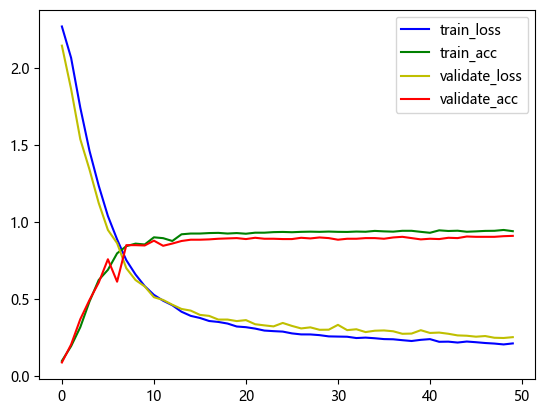

best_accuracy : 0.9083333333333333


In [5]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font", family='Microsoft YaHei')

def model_train(batch_size, epochs, train_loader, val_loader, model, optimizer, loss_function, device):
    model = model.to(device)
    # 样本长度
    train_size = len(train_loader) * batch_size
    val_size = len(val_loader) * batch_size

    # 最高准确率  最佳模型
    best_accuracy = 0.0
    best_model = model

    train_loss = []     # 记录在训练集上每个epoch的loss的变化情况
    train_acc = []    # 记录在训练集上每个epoch的准确率的变化情况
    validate_acc = []
    validate_loss = []

    # 计算模型运行时间
    start_time = time.time()
    for epoch in range(epochs):
        # 训练
        model.train()
        loss_epoch = 0.    #保存当前epoch的loss和
        correct_epoch = 0  #保存当前epoch的正确个数和
        for batchdata  in train_loader: 
            batchdata = batchdata.to(device)  # 将数据移动到设备
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(batchdata)  
            # 对模型输出进行softmax操作，得到概率分布
            probabilities = F.softmax(y_pred, dim=1)
            # 得到预测的类别
            predicted_labels = torch.argmax(probabilities, dim=1)
            # 与真实标签进行比较，计算预测正确的样本数量  # 计算当前batch预测正确个数
            correct_epoch += (predicted_labels == batchdata.y).sum().item()
            # 损失计算
            loss = loss_function(y_pred, batchdata.y)
            loss_epoch += loss.item()
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
        #     break
        # break
        # 计算准确率
        train_Accuracy  = correct_epoch/train_size 
        train_loss.append(loss_epoch/train_size)
        train_acc.append(train_Accuracy)
        print(f'Epoch: {epoch+1:2} train_Loss: {loss_epoch/train_size:10.8f} train_Accuracy:{train_Accuracy:4.4f}')
        # 每一个epoch结束后，在验证集上验证实验结果。
        with torch.no_grad():
            # 将模型设置为评估模式
            model.eval()
            loss_validate = 0.
            correct_validate = 0
            for valbatch in val_loader:
                valbatch = valbatch.to(device)  # 将数据移动到设备
                pre = model(valbatch)
                # 对模型输出进行softmax操作，得到概率分布
                probabilities = F.softmax(pre, dim=1)
                # 得到预测的类别
                predicted_labels = torch.argmax(probabilities, dim=1)
                # 与真实标签进行比较，计算预测正确的样本数量  # 计算当前batch预测正确个数
                correct_validate += (predicted_labels == valbatch.y).sum().item()
                loss = loss_function(pre, valbatch.y)
                loss_validate += loss.item()
            # print(f'validate_sum:{loss_validate},  validate_Acc:{correct_validate}')
            val_accuracy = correct_validate/val_size 
            print(f'Epoch: {epoch+1:2} val_Loss:{loss_validate/val_size:10.8f},  validate_Acc:{val_accuracy:4.4f}')
            validate_loss.append(loss_validate/val_size)
            validate_acc.append(val_accuracy)
            # 如果当前模型的准确率优于之前的最佳准确率，则更新最佳模型
            #保存当前最优模型参数
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_model = model# 更新最佳模型的参数

    # 保存最后的参数
    # torch.save(model, 'final_model_gat.pt')
    # 保存最好的参数
    torch.save(best_model, 'best_model_gat.pt')
   
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    plt.plot(range(epochs), train_loss, color = 'b',label = 'train_loss')
    plt.plot(range(epochs), train_acc, color = 'g',label = 'train_acc')
    plt.plot(range(epochs), validate_loss, color = 'y',label = 'validate_loss')
    plt.plot(range(epochs), validate_acc, color = 'r',label = 'validate_acc')
    plt.legend()
    plt.show()   #显示 lable 
    print("best_accuracy :", best_accuracy)
    
    # 保存结果 方便 后续画图处理（如果有需要的话）
    dump(train_loss, './matfiles/train_loss')
    dump(train_acc, './matfiles/train_acc')
    dump(validate_loss, './matfiles/validate_loss')
    dump(validate_acc, './matfiles/validate_acc')



batch_size = 32
epochs = 50
# 模型训练
model_train(batch_size, epochs, train_loader, val_loader, model, optimizer, loss_function, device)

In [6]:
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix

# 模型 测试集 验证  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 有GPU先用GPU训练

# 得出每一类的分类准确率
model = torch.load('best_model_gat.pt')
model = model.to(device)


# 使用测试集数据进行推断并计算每一类的分类准确率
true_labels = []  # 存储类别标签
predicted_labels = []  # 存储预测的标签

# 提取特征
test_original_features = []  # 原始测试集 特征
test_model_features = []  # 测试集经过训练后的模型得到的 特征

# 使用测试集数据进行推断并计算每一类的分类准确率
class_labels = []  # 存储类别标签
predicted_labels = []  # 存储预测的标签



with torch.no_grad():
    for testbatch in test_loader:
        # 将模型设置为评估模式
        model.eval()
        testbatch = testbatch.to(device)  # 将数据移动到设备
        test_output = model(testbatch)
        probabilities = F.softmax(test_output, dim=1)
        predicted = torch.argmax(probabilities, dim=1)
        class_labels.extend(testbatch.y.tolist())
        predicted_labels.extend(predicted.tolist())

# 混淆矩阵
confusion_mat = confusion_matrix(class_labels, predicted_labels)

from sklearn.metrics import classification_report
# 计算每一类的分类准确率
report = classification_report(class_labels, predicted_labels, digits=4)
print(report)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        25
           1     0.9667    1.0000    0.9831        29
           2     1.0000    1.0000    1.0000        21
           3     0.7619    0.6957    0.7273        23
           4     1.0000    1.0000    1.0000        20
           5     0.8500    0.9444    0.8947        18
           6     1.0000    1.0000    1.0000        22
           7     1.0000    1.0000    1.0000        30
           8     0.8571    0.8182    0.8372        22
           9     1.0000    1.0000    1.0000        23

    accuracy                         0.9485       233
   macro avg     0.9436    0.9458    0.9442       233
weighted avg     0.9473    0.9485    0.9475       233



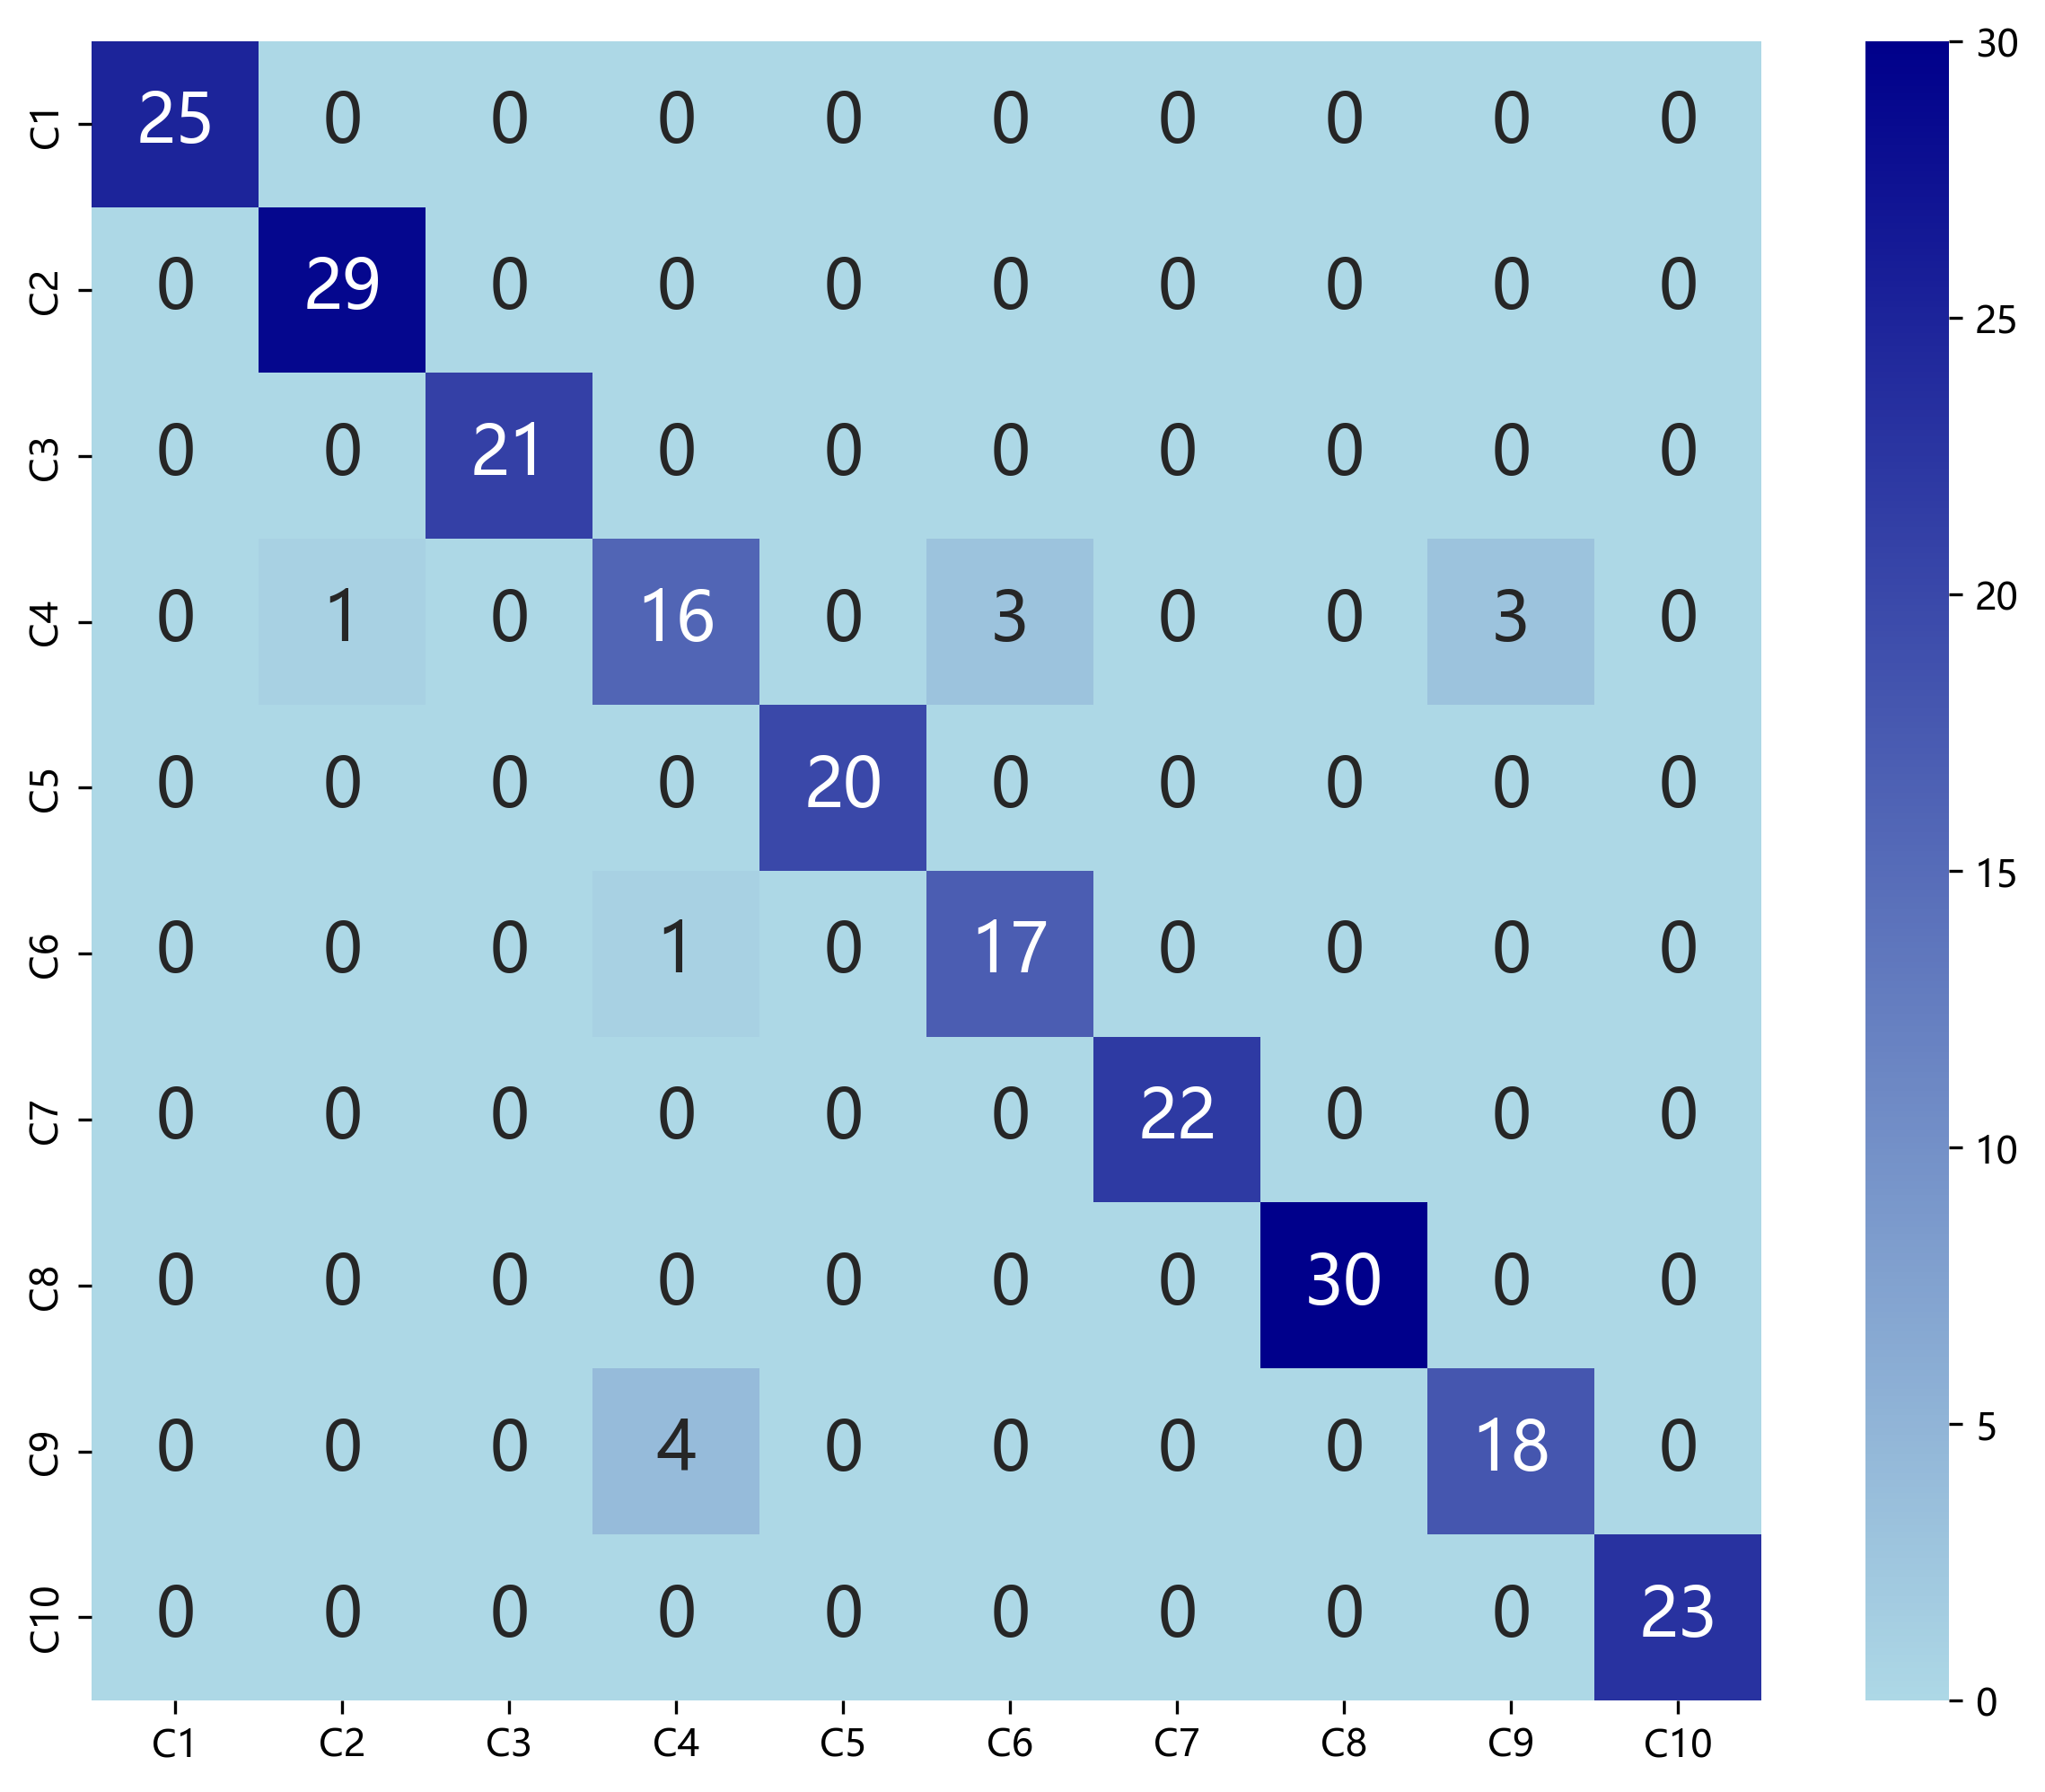

In [11]:
# 绘制混淆矩阵
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# 原始标签和自定义标签的映射
label_mapping = {
    0: "C1",1: "C2",2: "C3",3: "C4",4: "C5",
    5: "C6",6: "C7",7: "C8",8: "C9",9: "C10",
}

# 自定义颜色映射：从浅蓝色到深蓝色
colors = ["#ADD8E6", "#00008B"]  # 浅蓝色 (#ADD8E6) 到深蓝色 (#0000FF)
cmap = LinearSegmentedColormap.from_list("custom_blues", colors)

# 绘制混淆矩阵
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(confusion_mat,  xticklabels=label_mapping.values(), yticklabels=label_mapping.values(),annot=True ,annot_kws={'size': 18}, fmt='d', cmap=cmap)#原来‘summer’也可以
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix')
plt.show()

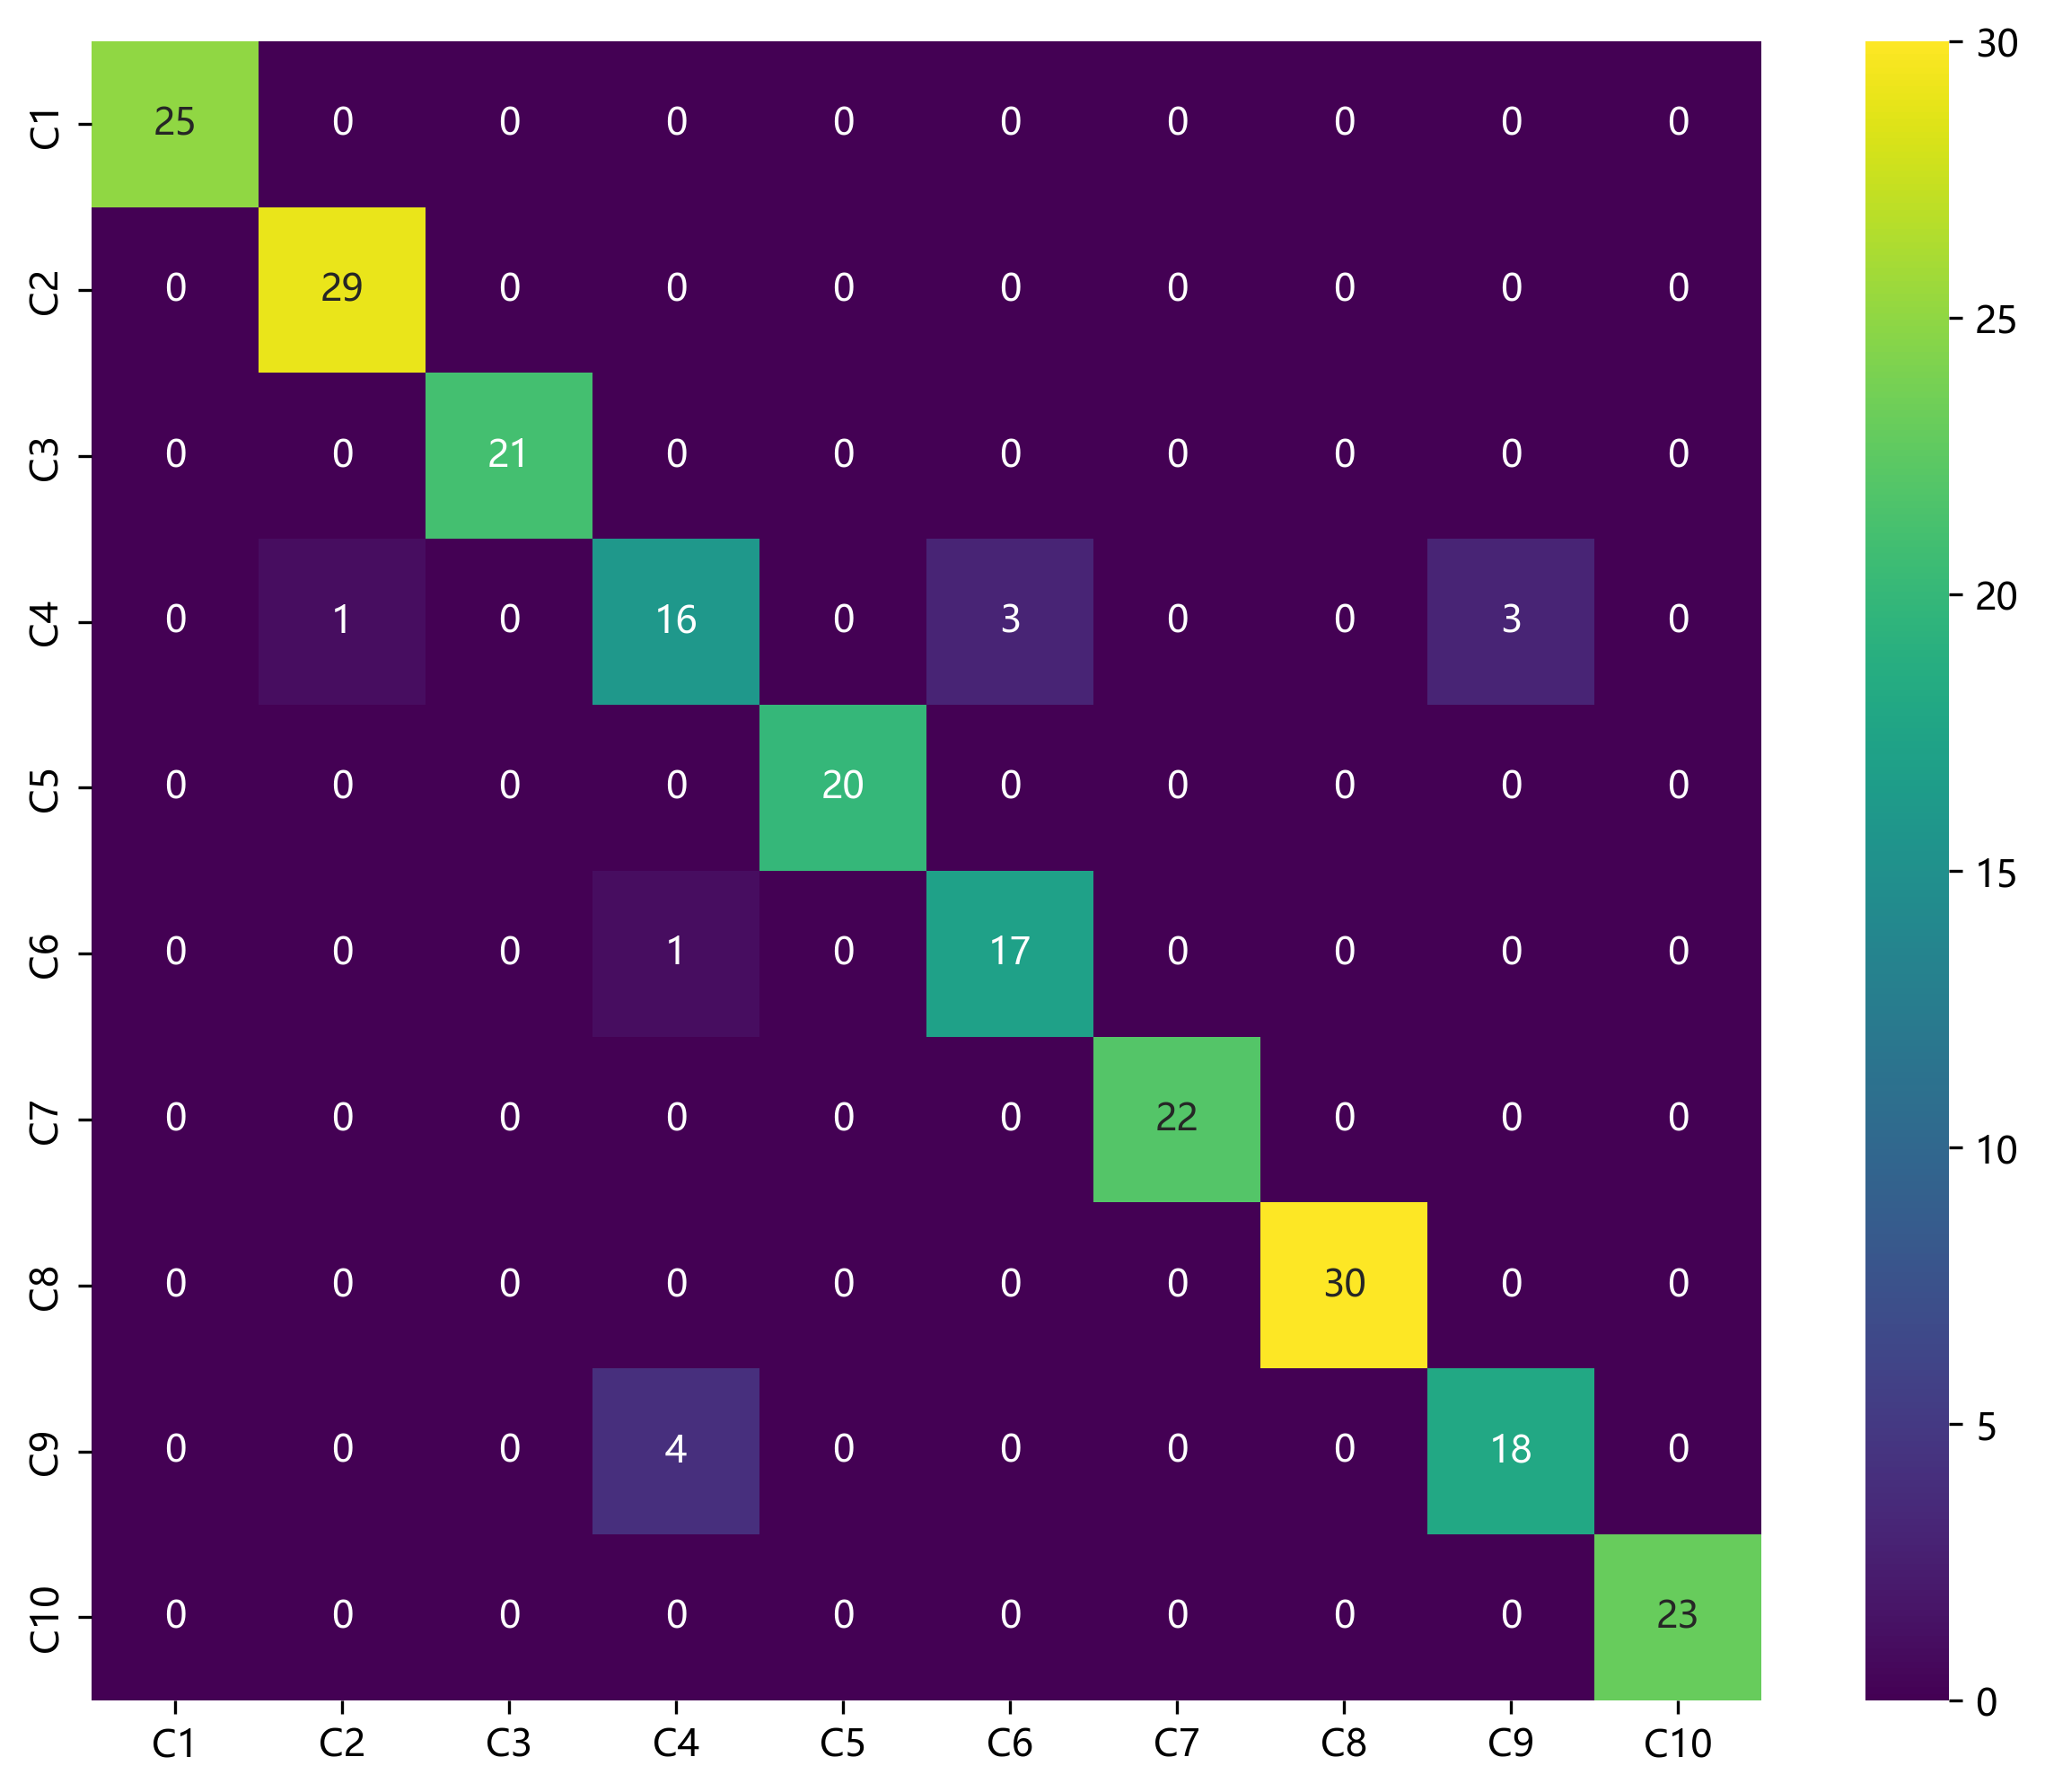

In [8]:
# 绘制混淆矩阵
import matplotlib.pyplot as plt
import seaborn as sns
# 原始标签和自定义标签的映射
label_mapping = {
    0: "C1",1: "C2",2: "C3",3: "C4",4: "C5",
    5: "C6",6: "C7",7: "C8",8: "C9",9: "C10",
}

# 绘制混淆矩阵
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(confusion_mat,  xticklabels=label_mapping.values(), yticklabels=label_mapping.values(),annot=True, fmt='d', cmap='viridis')
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix')
plt.show()

In [9]:
# 原始数据集t-SNE可视化
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')
from sklearn.manifold import TSNE
from joblib import load

# 参数设置
num_classes = 10
class_labels_name = ['de_normal', 'de_7_inner', 'de_7_ball', 'de_7_outer', 'de_14_inner',
                'de_14_ball', 'de_14_outer', 'de_21_inner', 'de_21_ball', 'de_21_outer']

# 加载测试集
test_dataset = load('test_dataset')

# 提取原始特征和标签
test_original_features = [data.x.numpy().flatten() for data in test_dataset]  # 使用原始信号特征
true_labels = [data.y.item() for data in test_dataset]

# 可视化函数
def plot_original_tsne(features, labels, num_classes, class_labels):
    features = np.array(features)
    labels = np.array(labels)
    
    tsne = TSNE(n_components=2, random_state=42)
    features_tsne = tsne.fit_transform(features)
    
    plt.figure(figsize=(10, 8), dpi=100)
    for i in range(num_classes):
        plt.scatter(features_tsne[labels == i, 0],
                    features_tsne[labels == i, 1],
                    label=class_labels[i],
                    alpha=0.8)
    plt.title('Visualization of the original test set TSNE')
    plt.xlabel('tSNE Dimension 1')
    plt.ylabel('tSNE Dimension 2')
    plt.legend()
    plt.savefig('./matfiles/原始测试集TSNE可视化', dpi=300)
    plt.close()

# 执行可视化
plot_original_tsne(test_original_features, true_labels, num_classes, class_labels_name)

In [10]:
# 分类后数据TSNE可视化
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')
from sklearn.manifold import TSNE
import torch
from torch_geometric.loader import DataLoader
from joblib import load

# 参数设置
num_classes = 10  # 与你的原始代码完全一致
class_labels_name = ['de_normal', 'de_7_inner', 'de_7_ball', 'de_7_outer', 'de_14_inner',
                     'de_14_ball', 'de_14_outer', 'de_21_inner', 'de_21_ball', 'de_21_outer']  # 使用相同标签名

# 分类数据可视化函数
def plot_classified_TSNE(test_model_features, true_labels, num_classes, class_labels_name):
    features = np.array(test_model_features)
    labels = np.array(true_labels)

    print(features.shape)  # 应与模型输出维度一致 (样本数, 10)
    # 初始化 t-SNE 模型（参数与原始代码完全一致）
    tsne = TSNE(n_components=2, random_state=42)

    # 对分类特征进行降维
    features_tsne = tsne.fit_transform(features)
    print(features_tsne.shape)  # (样本数, 2)

    # 可视化（完全复用原始代码风格）
    plt.figure(figsize=(10, 8), dpi=300)
    for i in range(num_classes):
        plt.scatter(features_tsne[labels == i, 0],
                    features_tsne[labels == i, 1],
                    label=class_labels_name[i],
                    alpha=0.8)
    #plt.title('Visualization of the classification data test set TSNE')  # 仅修改标题区分
    plt.xlabel('tSNE Dimension 1')        # 坐标轴标签与原始代码一致
    plt.ylabel('tSNE Dimension 2')
    plt.legend(fontsize=14)
    plt.savefig('./matfiles/分类测试集TSNE可视化', dpi=300)  # 保存路径格式一致
    plt.close()

# --------------------- 执行部分 ---------------------
if __name__ == "__main__":
    # 加载测试集
    test_dataset = load('test_dataset')
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # 加载最佳模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = torch.load('best_model_gat.pt').to(device)
    model.eval()

    # 提取模型特征（与原始代码变量名风格一致）
    test_model_features = []
    true_labels = []
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            output = model(data)  # 获取分类前的特征输出
            test_model_features.extend(output.cpu().numpy())
            true_labels.extend(data.y.cpu().numpy())

    # 执行可视化
    plot_classified_TSNE(test_model_features, true_labels, num_classes, class_labels_name)

(233, 10)
(233, 2)
